<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/VanillaCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [36]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cpu



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [37]:
def evaluate_classifier(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.shape[0]
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += X_batch.shape[0]
    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc

def train_classifier(model, train_loader, test_loader=None, epochs=5, learning_rate=1e-3, verbose=True, enable_scheduler=False):
    # Train a PyTorch classifier using cross-entropy loss.
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    scheduler = None
    if enable_scheduler:
        # Add a learning rate scheduler (StepLR)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # Reduce LR by 0.5 every 5 epochs

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }


    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

        if scheduler:
            scheduler.step()

        train_loss = total_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        current_lr = optimizer.param_groups[0]['lr']

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            # if verbose:
            #     print(
            #         f"Epoch {epoch + 1}/{epochs}: "
            #         f"lr = {current_lr:.6f}, " # Added learning rate
            #         f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}, "
            #         f"test loss = {test_loss:.4f}, test acc = {test_acc:.4f}"
            #     )

        # else:
        #     if verbose:
        #         print(
        #             f"Epoch {epoch + 1}/{epochs}: "
        #             f"lr = {current_lr:.6f}, " # Added learning rate
        #             f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}"
        #         )

    return history


## 4. Helper Function: Plot Training Curves


In [38]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [40]:
from re import X
ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


(1000, 12, 2500)
(1000,)



## 11. Visualize Example Time Series


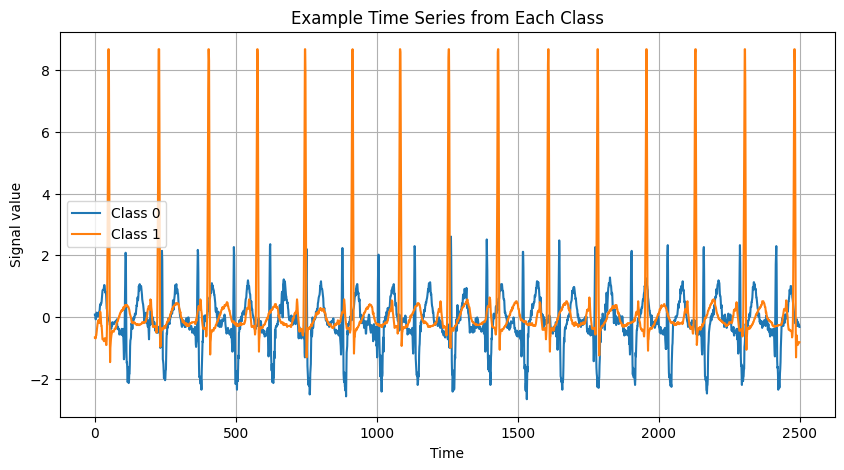

In [41]:
t = np.arange(X_ts.shape[2]) # Define the time axis

plt.figure(figsize=(10, 5))
# Iterate only over the unique class labels present in y_ts
for class_label in np.unique(y_ts):
    # Find the index of the first occurrence of the current class_label
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()


## 12. Create PyTorch DataLoaders for Time Series


In [42]:

X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
# print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

# print("Time-series training samples:", len(ts_train_dataset))
# print("Time-series test samples:", len(ts_test_dataset))


torch.Size([32, 12, 2500])
Time-series training samples: 800
Time-series test samples: 200



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [43]:
class TimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — compress heavily with large kernel
            nn.Conv1d(in_channels, 8, kernel_size=13, padding=6),
            nn.ReLU(),
            nn.Dropout(0.2), # Reduced dropout
            nn.AvgPool1d(kernel_size=5),   # 2500 → 500

            # Block 2 — compress again
            nn.Conv1d(8, 12, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Dropout(0.2), # Reduced dropout
            nn.AvgPool1d(kernel_size=5),   # 500 → 100

            # Block 3 — final compression
            nn.Conv1d(12, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5),   # 100 → 20

            # Block 4 — final compression
            nn.Conv1d(16, 20, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5),   # 20 → 4


        )

        # 16 filters * 20 timesteps = 320 — much smaller than before (9984)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(20 * 4, 20),
            nn.ReLU(),
            nn.Dropout(0.2), # Keep dropout in classifier
            nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.features(x);
        x = self.classifier(x);
        return x

ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2);
# print(ts_model);

TimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 8, kernel_size=(13,), stride=(1,), padding=(6,))
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (4): Conv1d(8, 12, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (8): Conv1d(12, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (11): Conv1d(16, 20, kernel_size=(5,), stride=(1,), padding=(2,))
    (12): ReLU()
    (13): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=80, out_features=20, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=20, out_features=2, bias=True)
  )
)


### 13.1 Define a Simplified 1D CNN for Time-Series Classification

Here is an alternative model architecture, `SimplifiedTimeSeriesConvNet`, which uses fewer convolutional blocks and Max Pooling for faster downsampling. The goal is to demonstrate a different layout while keeping the overall complexity manageable.

In [44]:
class SimplifiedTimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7), # Larger kernel to capture more context
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5),   # 2500 -> 500
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5),   # 500 -> 100
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5),   # 100 -> 20
            nn.Dropout(0.2)
        )

        # Calculate the size of the flattened features
        # This requires a dummy pass or careful calculation
        # After 3 MaxPool1d(5), sequence length becomes 2500 / 5 / 5 / 5 = 20
        # Number of output channels is 128 (was 64)
        final_feature_size = 128 * 20

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(final_feature_size, 64), # Adjusted to new feature size
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate the new model
simplified_ts_model = SimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
# print("Simplified Model Architecture:")
# print(simplified_ts_model);

Simplified Model Architecture:
SimplifiedTimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 32, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): ReLU()
    (6): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): ReLU()
    (10): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


### 14.1 Train the Simplified 1D CNN

Now, let's train this new, simplified model using the same training function.

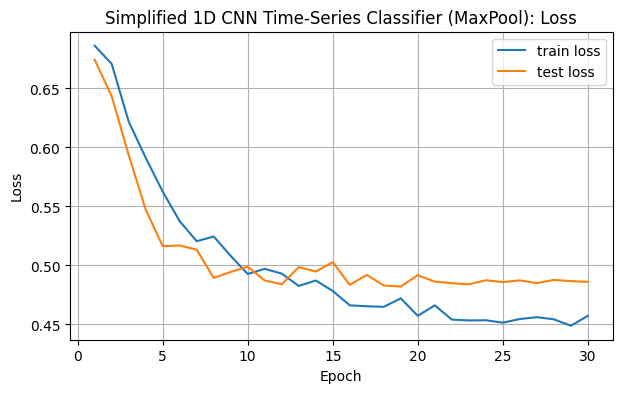

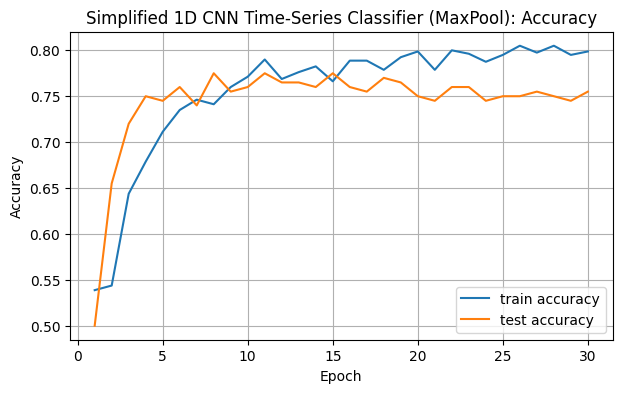

In [45]:
simplified_ts_model = SimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
simplified_ts_history = train_classifier(
    simplified_ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=30,
    learning_rate=3e-4,
    verbose=True,
    enable_scheduler=True
)

plot_history(simplified_ts_history, title="Simplified 1D CNN Time-Series Classifier (MaxPool)")

### 15.1 Improved Simplified 1D CNN Architecture

This version of the simplified model includes Batch Normalization layers and increased filter counts to potentially improve learning stability and feature extraction capabilities.

In [46]:
class ImprovedSimplifiedTimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1:
            nn.Conv1d(in_channels, 48, kernel_size=13, padding=6), # padding for kernel 13: (13-1)//2 = 6
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 2500 -> 500
            nn.Dropout(0.2),

            # Block 2:
            nn.Conv1d(48, 96, kernel_size=7, padding=3), # padding for kernel 7: (7-1)//2 = 3
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 500 -> 100
            nn.Dropout(0.2),

            # Block 3:
            nn.Conv1d(96, 192, kernel_size=5, padding=2), # padding for kernel 5: (5-1)//2 = 2
            nn.BatchNorm1d(192),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 100 -> 20
            nn.Dropout(0.2),

            # Block 4:
            nn.Conv1d(192, 384, kernel_size=3, padding=1), # padding for kernel 3: (3-1)//2 = 1
            nn.BatchNorm1d(384),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=5), # 20 -> 4
            nn.Dropout(0.2)
        )

        # Calculate the size of the flattened features
        # After 4 AvgPool1d(5), sequence length becomes 2500 -> 500 -> 100 -> 20 -> 4
        # Number of output channels is 384
        final_feature_size = 384 * 4

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(final_feature_size, 128), # Adjusted to new feature size and wider hidden layer
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate the improved model
improved_ts_model = ImprovedSimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
# print("Improved Simplified Model Architecture (with BatchNorm1d, AdaptiveAvgPool1d, 4 layers, filters (48,96,192,384), dropout=0.2):")
# print(improved_ts_model);

Improved Simplified Model Architecture (with BatchNorm1d, AdaptiveAvgPool1d, 4 layers, filters (48,96,192,384), dropout=0.2):
ImprovedSimplifiedTimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 48, kernel_size=(13,), stride=(1,), padding=(6,))
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(48, 96, kernel_size=(7,), stride=(1,), padding=(3,))
    (6): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(96, 192, kernel_size=(5,), stride=(1,), padding=(2,))
    (11): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
    (14): Dr

### 15.2 Train the Improved Simplified 1D CNN

Now, let's train this new, improved simplified model using the same training function.

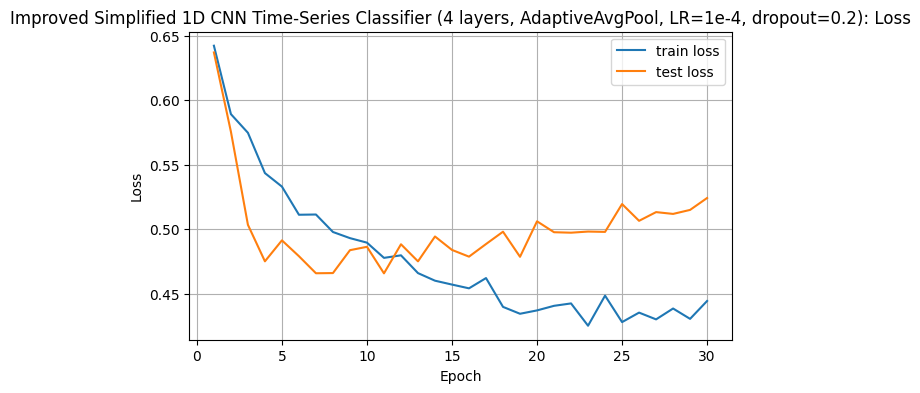

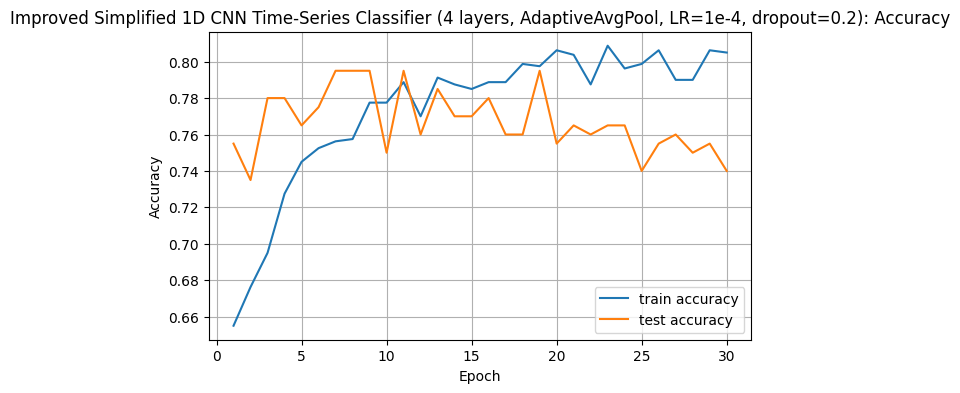

In [47]:
improved_ts_model = ImprovedSimplifiedTimeSeriesConvNet(sequence_length=2500, num_classes=2);
improved_simplified_ts_history = train_classifier(
    improved_ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=30,
    learning_rate=1e-4,
    verbose=True,
    enable_scheduler=True
)

plot_history(improved_simplified_ts_history, title="Improved Simplified 1D CNN Time-Series Classifier (4 layers, AdaptiveAvgPool, LR=1e-4, dropout=0.2)")


## 14. Train the 1D CNN


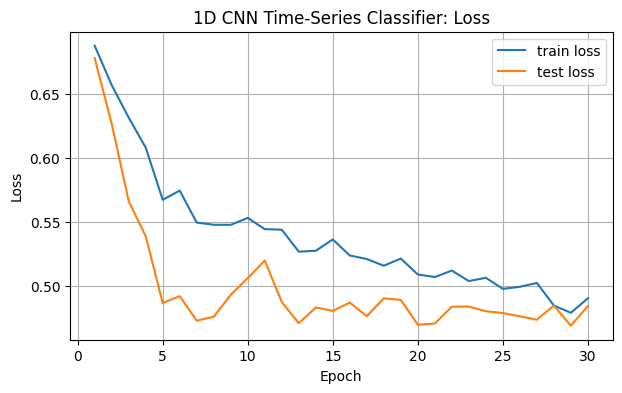

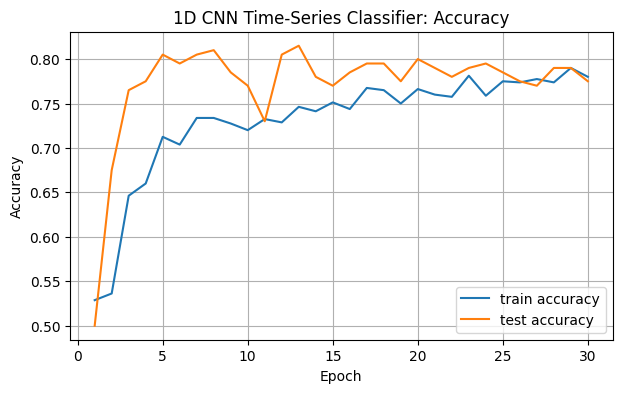

In [48]:
ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2);
ts_history = train_classifier(
    ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=30,
    learning_rate=1.3e-3,
    verbose=True,
    enable_scheduler=False
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")

## 17. Model Performance Comparison

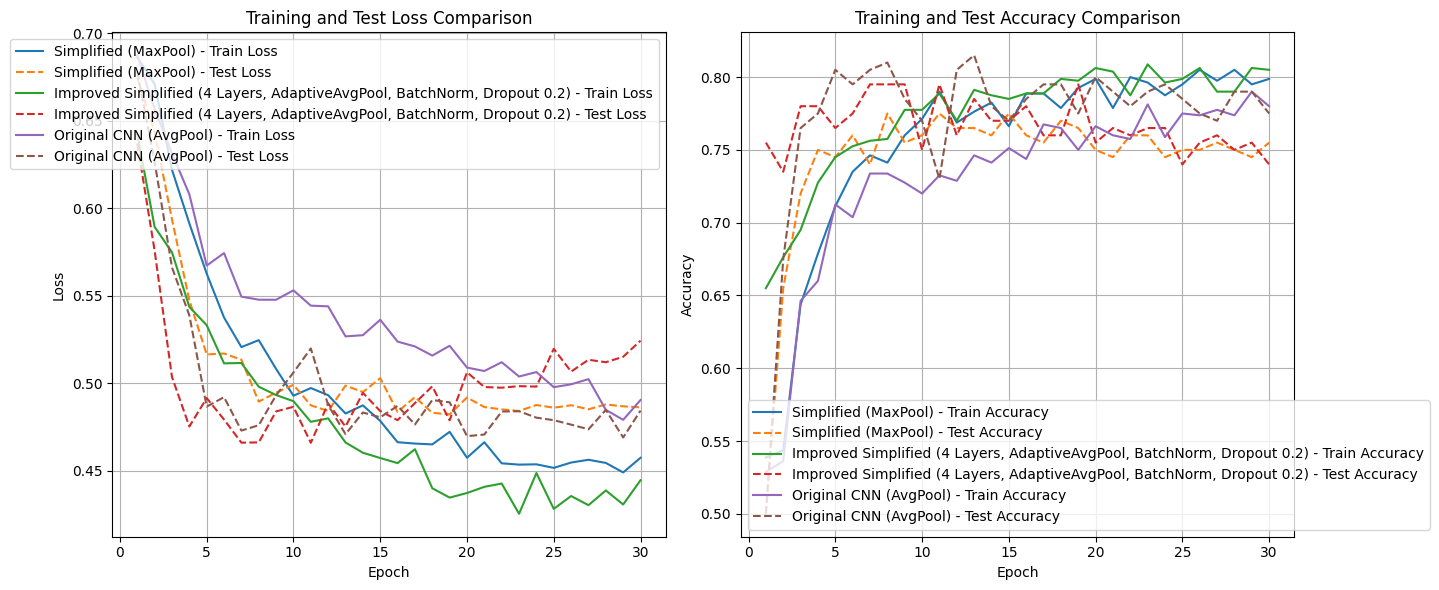

In [49]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_histories(histories_dict):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot Loss
    for model_name, history in histories_dict.items():
        epochs = np.arange(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs, history['train_loss'], label=f'{model_name} - Train Loss', linestyle='-')
        if len(history['test_loss']) > 0:
            axes[0].plot(epochs, history['test_loss'], label=f'{model_name} - Test Loss', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Test Loss Comparison')
    axes[0].grid(True)
    axes[0].legend()

    # Plot Accuracy
    for model_name, history in histories_dict.items():
        epochs = np.arange(1, len(history['train_acc']) + 1)
        axes[1].plot(epochs, history['train_acc'], label=f'{model_name} - Train Accuracy', linestyle='-')
        if len(history['test_acc']) > 0:
            axes[1].plot(epochs, history['test_acc'], label=f'{model_name} - Test Accuracy', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Test Accuracy Comparison')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Collect all histories into a dictionary
all_histories = {
    "Simplified (MaxPool)": simplified_ts_history,
    "Improved Simplified (4 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.2)": improved_simplified_ts_history,
    "Original CNN (AvgPool)": ts_history
}

# Plot the combined histories
plot_all_histories(all_histories)


## 15. Inspect Time-Series Predictions


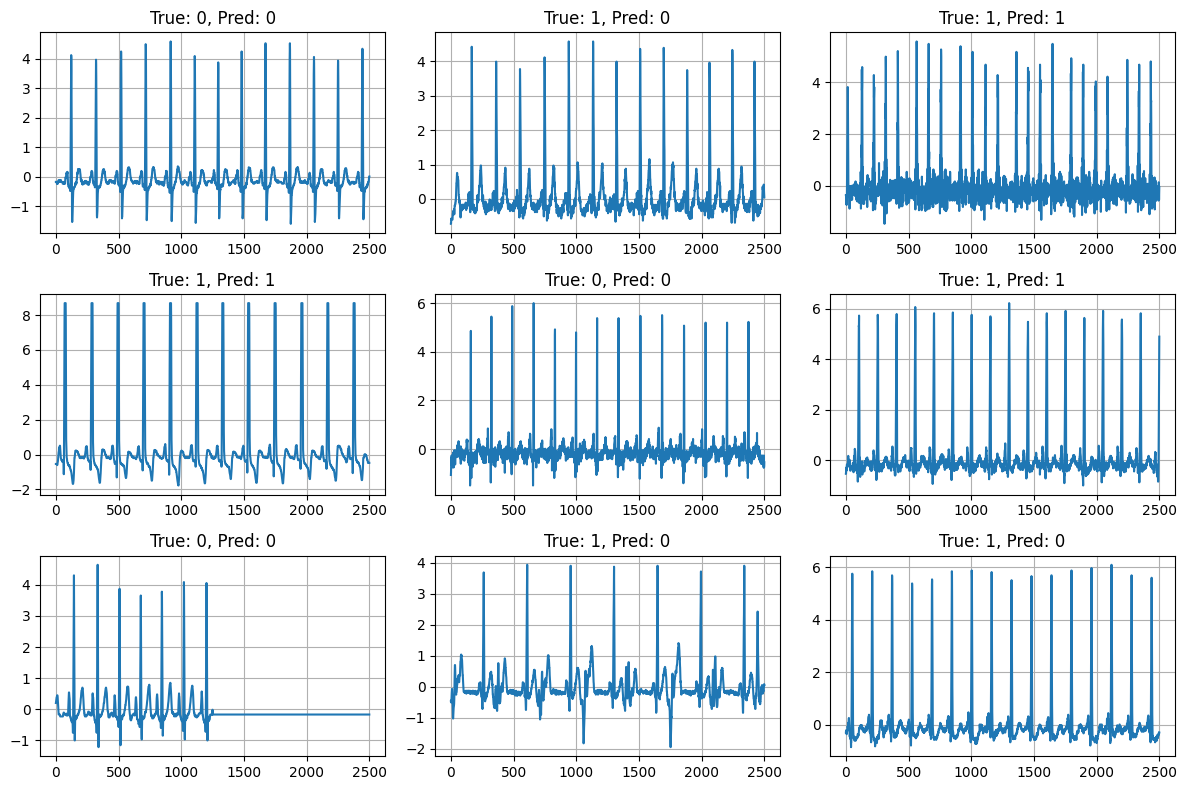

In [50]:
# improved_ts_model.eval()

# X_batch, y_batch = next(iter(ts_test_loader))

# with torch.no_grad():
#     logits = improved_ts_model(X_batch.to(device))
#     predictions = torch.argmax(logits, dim=1).cpu()

# plt.figure(figsize=(12, 8))
# for i in range(9):
#     plt.subplot(3, 3, i + 1)
#     plt.plot(X_batch[i, 0].numpy())
#     plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()


## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


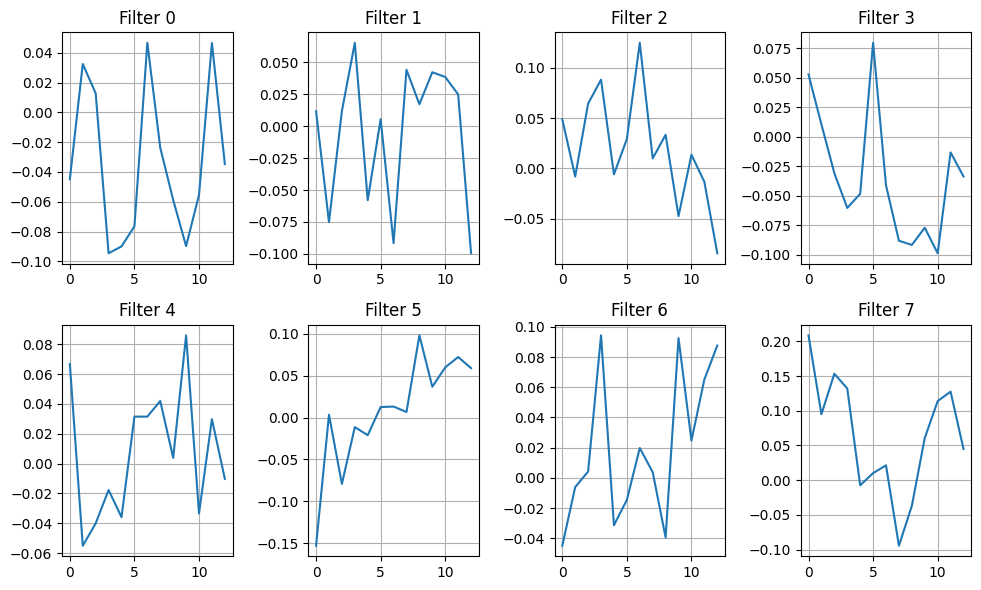

In [51]:

first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()



In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [54]:
def as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):

    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):

    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [55]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):

    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        all_y.append(y.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [56]:
def confusion_counts(y_true, y_pred):

    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [57]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [58]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [59]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [60]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [61]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [62]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [63]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [64]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):

    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [65]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):

    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):

    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [66]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):

    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [67]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [68]:
ts_model.to(device)
simplified_ts_model.to(device)
improved_ts_model.to(device)

ts_metrics, ts_y_true, ts_probs, ts_y_pred = evaluate_standard_nn_classifier(
    model=ts_model,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

simplified_ts_metrics, simplified_ts_y_true, simplified_ts_probs, simplified_ts_y_pred = evaluate_standard_nn_classifier(
    model=simplified_ts_model,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

improved_simplified_ts_metrics, improved_simplified_ts_y_true, improved_simplified_ts_probs, improved_simplified_ts_y_pred = evaluate_standard_nn_classifier(
    model=improved_ts_model,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

comparison_df = pd.DataFrame(
    [
        ts_metrics,
        simplified_ts_metrics,
        improved_simplified_ts_metrics
    ],
    index=[
        "Original CNN (AvgPool)",
        "Simplified (MaxPool)",
        "Improved Simplified (4 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.2)"
    ]
).T

display(comparison_df)

,Original CNN (AvgPool),Simplified (MaxPool),"Improved Simplified (4 Layers, AdaptiveAvgPool, BatchNorm, Dropout 0.2)"
accuracy,0.775000,0.755000,0.740000
balanced_accuracy,0.775000,0.755000,0.740000
auroc,0.837300,0.840100,0.848700
auprc,0.854309,0.860350,0.865801
sensitivity,0.680000,0.690000,0.560000
specificity,0.870000,0.820000,0.920000
negative_log_likelihood,0.484300,0.486145,0.524260
brier_score,0.159324,0.159492,0.174812
expected_calibration_error,0.057469,0.026730,0.050662
tn,87.000000,82.000000,92.000000


Confusion matrix [[TN, FP], [FN, TP]]:
[[92  8]
 [44 56]]


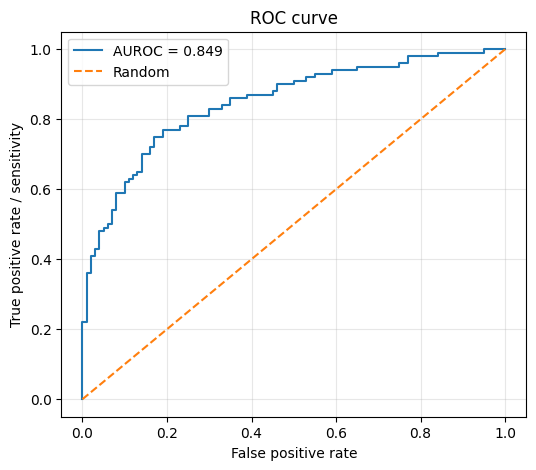

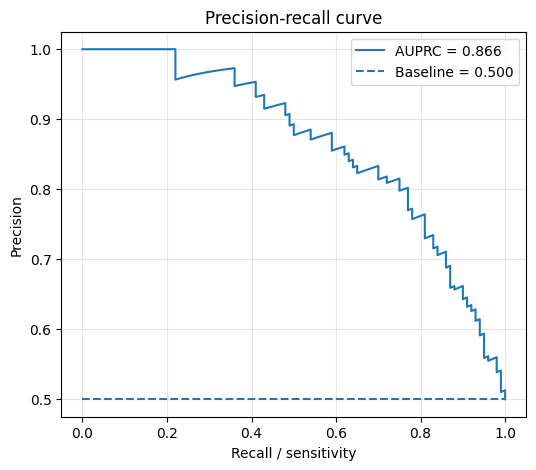

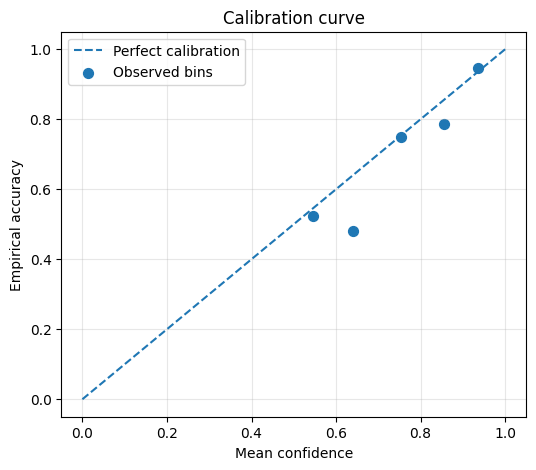

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,21,0.545028,0.523810,0.021219
6,7,0.6,0.7,27,0.639867,0.481481,0.158385
7,8,0.7,0.8,44,0.753776,0.750000,0.003776
8,9,0.8,0.9,70,0.854981,0.785714,0.069266
9,10,0.9,1.0,38,0.936956,0.947368,0.010412


In [69]:

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)
plot_calibration_curve(y_true_test, probs, n_bins=10)
calibration_table(y_true_test, probs, n_bins=10)


In [ ]:
cnn_ytest = y_true_test
cnn_probs = probs
